# Import

In [1]:
import sys
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import numpy as np

# Remonte de deux niveaux (si ton notebook est dans /notebooks/exploration.ipynb)
# pour atteindre la racine du projet
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
from config.config import *

In [2]:
df_images = pd.read_parquet(image_orientation)
df_images.head()

,name,features,path,orientation,type,cluster_label,weak_orientation
0,05340cd4-3bb2-459d-9937-bf27d52d8351.jpg,"[0.40974900126457214, 0.8732983469963074, 0.17...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,side,cancer,-1,side
1,0c6f3641-60d9-4a76-abe5-de89d55d5f2c.jpg,"[0.6502299308776855, 0.721211314201355, 0.0541...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,cancer,1,top
2,0f718241-8f63-4b55-81ce-315324b51069.jpg,"[1.192965030670166, 1.1314507722854614, 0.1077...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,cancer,-1,top
3,11a7a426-4806-401e-98b2-b96e7094d1a6.jpg,"[0.4946941137313843, 0.4560645818710327, 0.174...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,cancer,-1,top
4,1c043dbb-4623-4769-8e5e-0223bd745040.jpg,"[0.4919051229953766, 0.35454875230789185, 0.39...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,cancer,-1,top


In [3]:
df_images_cancer_top= df_images[(df_images['orientation'] == 'top') & (df_images['type'] == 'cancer')]
df_images_cancer_top.head()

,name,features,path,orientation,type,cluster_label,weak_orientation
1,0c6f3641-60d9-4a76-abe5-de89d55d5f2c.jpg,"[0.6502299308776855, 0.721211314201355, 0.0541...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,cancer,1,top
2,0f718241-8f63-4b55-81ce-315324b51069.jpg,"[1.192965030670166, 1.1314507722854614, 0.1077...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,cancer,-1,top
3,11a7a426-4806-401e-98b2-b96e7094d1a6.jpg,"[0.4946941137313843, 0.4560645818710327, 0.174...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,cancer,-1,top
4,1c043dbb-4623-4769-8e5e-0223bd745040.jpg,"[0.4919051229953766, 0.35454875230789185, 0.39...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,cancer,-1,top
9,3c3d07cb-ec2a-43b0-b8a3-3a51573ad930.jpg,"[0.8727291822433472, 0.7392463088035583, 0.012...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,cancer,-1,top


In [4]:
df_images_normal_top= df_images[(df_images['orientation'] == 'top') & (df_images['type'] == 'normal')]
df_images_normal_top.head()

,name,features,path,orientation,type,cluster_label,weak_orientation
50,0161f9bf-fa93-4d02-8dce-84bfd49fe6a2.jpg,"[0.666938304901123, 0.8587964177131653, 0.0786...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,normal,1,top
51,09316c60-86c8-4f24-934e-8d433b8b9d72.jpg,"[0.27638107538223267, 1.021559715270996, 0.096...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,normal,1,top
52,11825cf3-9b35-42d3-ac99-21f26dd2f94e.jpg,"[0.24565695226192474, 0.7865098714828491, 0.11...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,normal,1,top
53,14703976-0467-4acb-ade4-8a375ebfd4f9.jpg,"[0.6598442196846008, 0.12885765731334686, 0.61...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,normal,-1,top
54,1953e998-29b8-4d36-975f-007c4fcb84a3.jpg,"[0.19154807925224304, 0.3241497278213501, 0.31...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,normal,-1,top


In [5]:
df_images_unknown_top = df_images[(df_images['weak_orientation'] == 'top') & (df_images['type'] == 'unknown')]
df_images_unknown_top.head()

,name,features,path,orientation,type,cluster_label,weak_orientation
100,001b158a-7af8-451e-bf31-3a9116265f3a.jpg,"[0.41991156339645386, 0.9218237996101379, 0.10...",NaN,unknown,unknown,-1,top
101,00366e8d-5520-4d3c-a70b-91a7eec1f521.jpg,"[0.36736008524894714, 0.7256330251693726, 0.49...",NaN,unknown,unknown,-1,top
102,00455a62-f79f-4072-9a23-4951e759acdc.jpg,"[0.4033546447753906, 0.5182491540908813, 0.215...",NaN,unknown,unknown,1,top
103,004ce5f5-ca6b-490f-9b2f-c322c152e2ee.jpg,"[0.3427850902080536, 0.9386187195777893, 0.403...",NaN,unknown,unknown,-1,top
104,005d9a37-8894-4eb5-8367-1015d4a43638.jpg,"[0.8467745184898376, 0.6339333057403564, 0.151...",NaN,unknown,unknown,-1,top


In [6]:
df = pd.concat([df_images_cancer_top,df_images_normal_top],ignore_index=True)
df.describe(include='all')

,name,features,path,orientation,type,cluster_label,weak_orientation
count,70,70,70,70,70,70.000000,70
unique,70,70,70,1,2,NaN,1
top,0c6f3641-60d9-4a76-abe5-de89d55d5f2c.jpg,"[0.6502299308776855, 0.721211314201355, 0.0541...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,normal,NaN,top
freq,1,1,1,70,48,NaN,70
mean,NaN,NaN,NaN,NaN,NaN,-0.557143,NaN
std,NaN,NaN,NaN,NaN,NaN,0.827704,NaN
min,NaN,NaN,NaN,NaN,NaN,-1.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,-1.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,-1.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,-1.000000,NaN


In [7]:
df['type'] = df['type'].map({'cancer':1,
                      'normal' : 0})
df = df[['name','path','type']]

In [8]:
df.head()

,name,path,type
0,0c6f3641-60d9-4a76-abe5-de89d55d5f2c.jpg,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,1
1,0f718241-8f63-4b55-81ce-315324b51069.jpg,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,1
2,11a7a426-4806-401e-98b2-b96e7094d1a6.jpg,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,1
3,1c043dbb-4623-4769-8e5e-0223bd745040.jpg,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,1
4,3c3d07cb-ec2a-43b0-b8a3-3a51573ad930.jpg,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,1


In [9]:
from sklearn.model_selection import train_test_split

df_train, df_val = train_test_split(
    df,
    test_size=0.2,
    stratify=df["type"],
    random_state=42
)
 

In [10]:
from torch.utils.data import Dataset
from PIL import Image

class BrainMRIDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "path"]
        label = self.df.loc[idx, "type"]

        img = Image.open(img_path).convert("RGB")
        img = self.transform(img)

        return img, label


In [11]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [12]:
from torch.utils.data import DataLoader

train_dataset = BrainMRIDataset(df_train, train_transform)
val_dataset   = BrainMRIDataset(df_val, train_transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False)


In [13]:
import torch
import torch.nn as nn
from torchvision import models

device = "cuda" if torch.cuda.is_available() else "cpu"

model = models.resnet50(pretrained=True)

# Gèle les couches convolutionnelles
for param in model.parameters():
    param.requires_grad = False

#remplace la couche finale du resnet par une couche de 2 choix
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.fc.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)


c:\Users\Fabien\Desktop\OC\P10\BrainScanAI\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Fabien\Desktop\OC\P10\BrainScanAI\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [14]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


In [15]:
from sklearn.metrics import f1_score, accuracy_score

def evaluate(model, loader):
    model.eval()
    y_true, y_pred = [], []
    total_loss = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            
            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    return {
        "loss": total_loss / len(loader),
        "f1": f1_score(y_true, y_pred),
        "accuracy": accuracy_score(y_true, y_pred)
    }

In [16]:
epochs = 15
f1_history = []
train_loss_history = []
val_loss_history = []

for epoch in range(epochs):
    train_loss = train_one_epoch(model, train_loader)
    metrics = evaluate(model, val_loader)
    
    train_loss_history.append(train_loss)
    val_loss_history.append(metrics['loss'])
    f1_history.append(metrics['f1'])
    
    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {metrics['loss']:.4f} | "
        f"F1: {metrics['f1']:.3f} | "
        f"Acc: {metrics['accuracy']:.3f}"
    )

Epoch 1/15 | Train Loss: 0.6565 | Val Loss: 0.5806 | F1: 0.000 | Acc: 0.714
Epoch 2/15 | Train Loss: 0.4949 | Val Loss: 0.3851 | F1: 0.667 | Acc: 0.857
Epoch 3/15 | Train Loss: 0.3605 | Val Loss: 0.3992 | F1: 0.667 | Acc: 0.857
Epoch 4/15 | Train Loss: 0.2531 | Val Loss: 0.3364 | F1: 0.667 | Acc: 0.857
Epoch 5/15 | Train Loss: 0.1946 | Val Loss: 0.3009 | F1: 0.667 | Acc: 0.857
Epoch 6/15 | Train Loss: 0.2120 | Val Loss: 0.2821 | F1: 0.667 | Acc: 0.857
Epoch 7/15 | Train Loss: 0.1899 | Val Loss: 0.2871 | F1: 0.667 | Acc: 0.857
Epoch 8/15 | Train Loss: 0.2507 | Val Loss: 0.2121 | F1: 0.857 | Acc: 0.929
Epoch 9/15 | Train Loss: 0.1667 | Val Loss: 0.2193 | F1: 0.667 | Acc: 0.857
Epoch 10/15 | Train Loss: 0.1111 | Val Loss: 0.1935 | F1: 1.000 | Acc: 1.000
Epoch 11/15 | Train Loss: 0.1279 | Val Loss: 0.1854 | F1: 1.000 | Acc: 1.000
Epoch 12/15 | Train Loss: 0.1615 | Val Loss: 0.1830 | F1: 1.000 | Acc: 1.000
Epoch 13/15 | Train Loss: 0.0774 | Val Loss: 0.1836 | F1: 1.000 | Acc: 1.000
Epoch 14

In [17]:
import numpy as np

np.mean(f1_history[-5:])


np.float64(1.0)

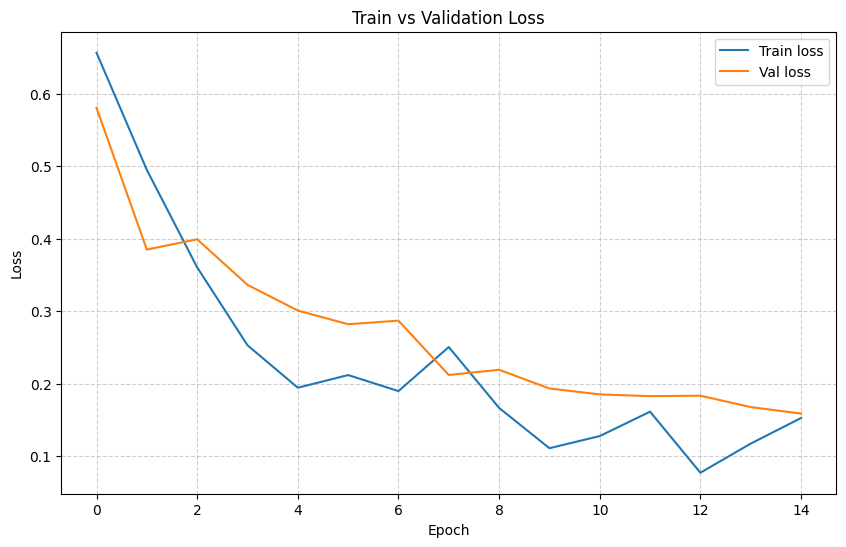

In [18]:
plt.figure(figsize=(10, 6))
plt.plot(train_loss_history, label="Train loss")
plt.plot(val_loss_history, label="Val loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

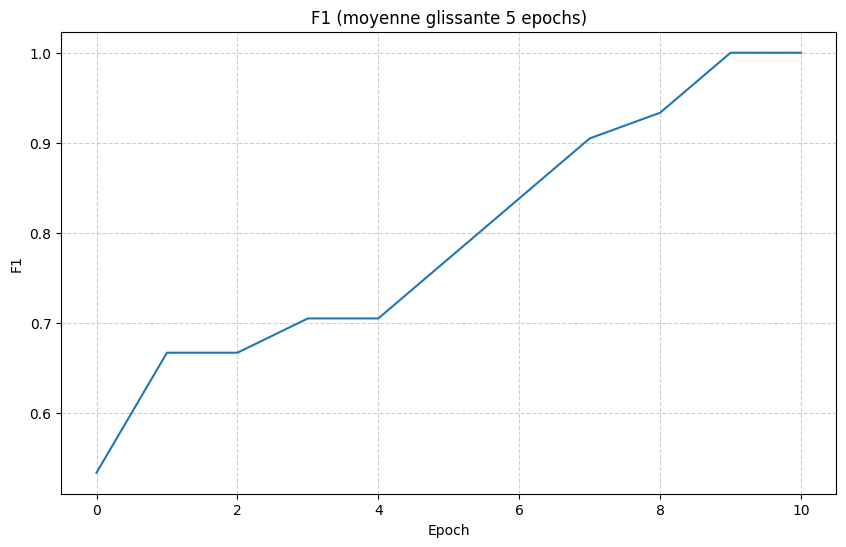

In [19]:
def moving_average(x, k=5):
    return np.convolve(x, np.ones(k)/k, mode="valid")

plt.figure(figsize=(10, 6))
plt.plot(moving_average(f1_history, 5))
plt.title("F1 (moyenne glissante 5 epochs)")
plt.xlabel("Epoch")
plt.ylabel("F1")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Matrice de Confusion
Visualisation des performances du modèle sur le jeu de validation.

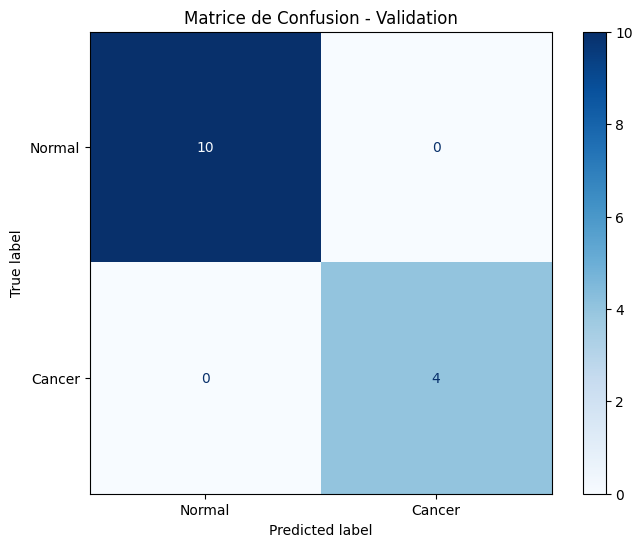

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Récupération des prédictions sur le jeu de validation
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Création de la matrice de confusion
cm = confusion_matrix(y_true, y_pred)
labels = ['Normal', 'Cancer']

# Affichage
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', ax=ax)
plt.title('Matrice de Confusion - Validation')
plt.show()